# Netflix Content Exploratory Data Analysis

## Thiranex Internship — Task 3

This project performs Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset.

### Objectives
- Explore and understand the Netflix dataset
- Perform data cleaning and preprocessing
- Generate statistical summaries
- Analyze distributions and trends
- Identify correlations and important factors
- Create meaningful visualizations
- Extract key insights from the data

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [47]:
file_path = "/content/drive/MyDrive/Thiranex/Task-3/netflix_titles.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (8807, 12)


In [48]:
# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [49]:
# Display last 5 rows
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [50]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [51]:
print("Columns in the dataset:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:
1. show_id
2. type
3. title
4. director
5. cast
6. country
7. date_added
8. release_year
9. rating
10. duration
11. listed_in
12. description


In [52]:
# Statistical summary for numerical columns
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [53]:
df.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [54]:
# Missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [55]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    by="Percentage",
    ascending=False
)

missing_table

,Missing Values,Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
release_year,0,0.000000


In [56]:
# Count duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [57]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (8807, 12)


In [58]:
# Fill missing categorical values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

# Date added will be handled separately
df["date_added"] = df["date_added"].fillna("Unknown")

print("Missing values handled.")

Missing values handled.


In [59]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [60]:
# Create a proper datetime column
df["date_added_clean"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

print("Date conversion completed.")

Date conversion completed.


In [61]:
df["year_added"] = df["date_added_clean"].dt.year
df["month_added"] = df["date_added_clean"].dt.month

df[["date_added", "date_added_clean", "year_added", "month_added"]].head()

,date_added,date_added_clean,year_added,month_added
0,"September 25, 2021",2021-09-25,2021.0,9.0
1,"September 24, 2021",2021-09-24,2021.0,9.0
2,"September 24, 2021",2021-09-24,2021.0,9.0
3,"September 24, 2021",2021-09-24,2021.0,9.0
4,"September 24, 2021",2021-09-24,2021.0,9.0


In [62]:
type_counts = df["type"].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


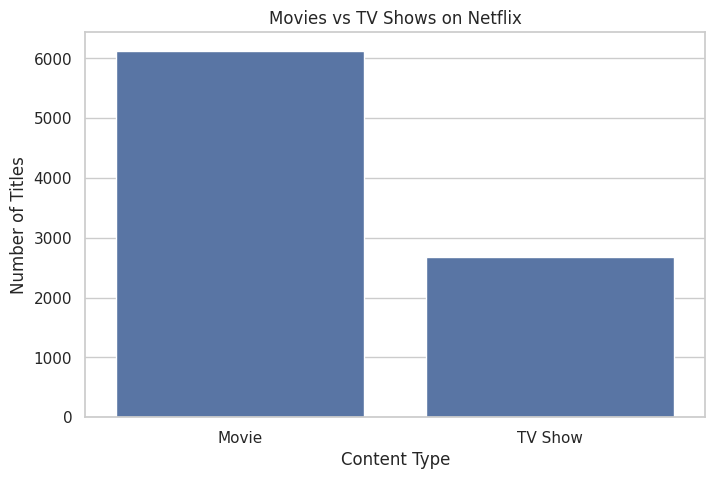

In [63]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [64]:
type_percentage = df["type"].value_counts(normalize=True) * 100

print(type_percentage.round(2))

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


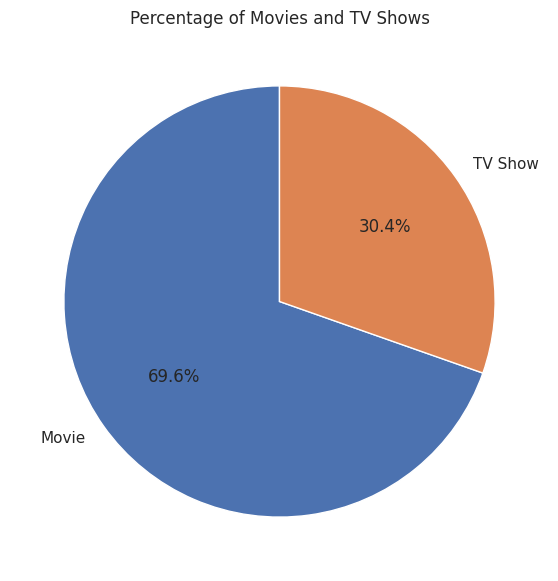

In [65]:
plt.figure(figsize=(7, 7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Movies and TV Shows")

plt.show()

In [66]:
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(20)

,count
release_year,
2002,51
2003,61
2004,64
2005,80
2006,96
2007,88
2008,136
2009,152
2010,194


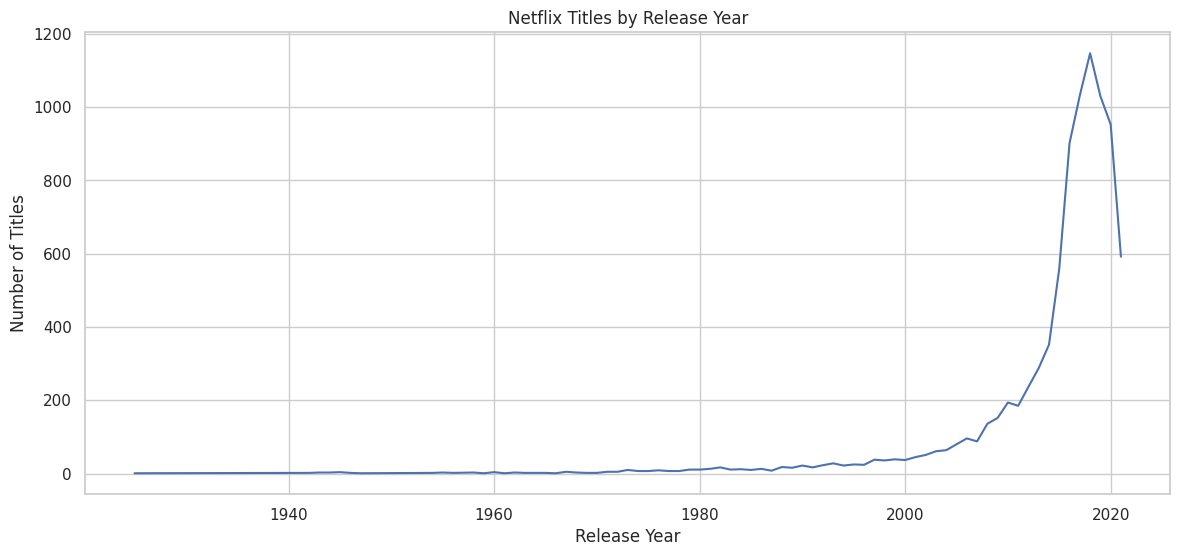

In [67]:
plt.figure(figsize=(14, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values
)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

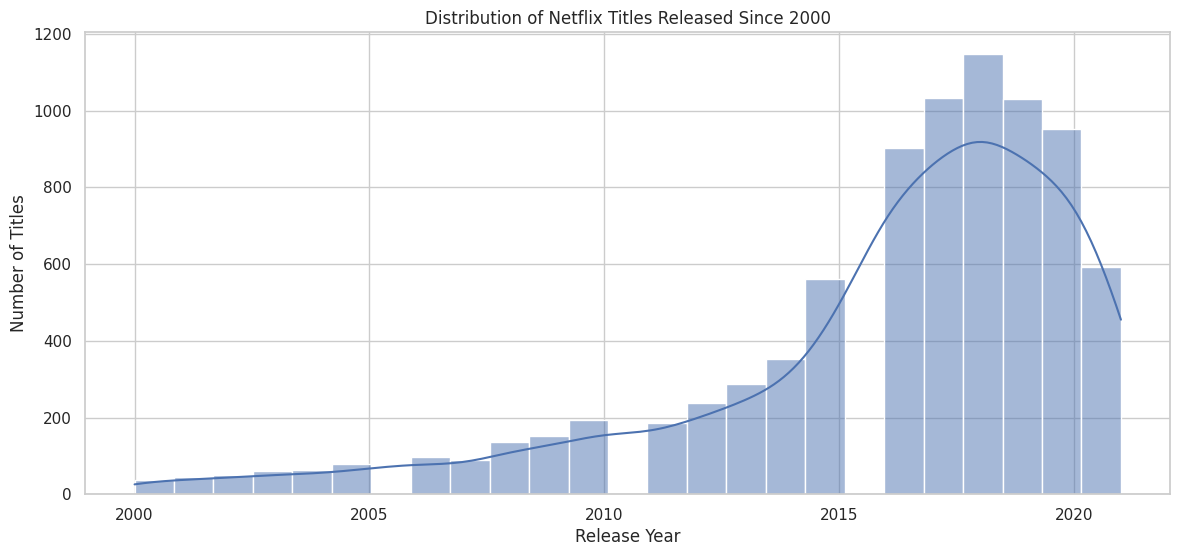

In [68]:
recent_years = df[
    df["release_year"] >= 2000
]

plt.figure(figsize=(14, 6))

sns.histplot(
    recent_years["release_year"],
    bins=25,
    kde=True
)

plt.title("Distribution of Netflix Titles Released Since 2000")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [69]:
titles_added_by_year = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

titles_added_by_year

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


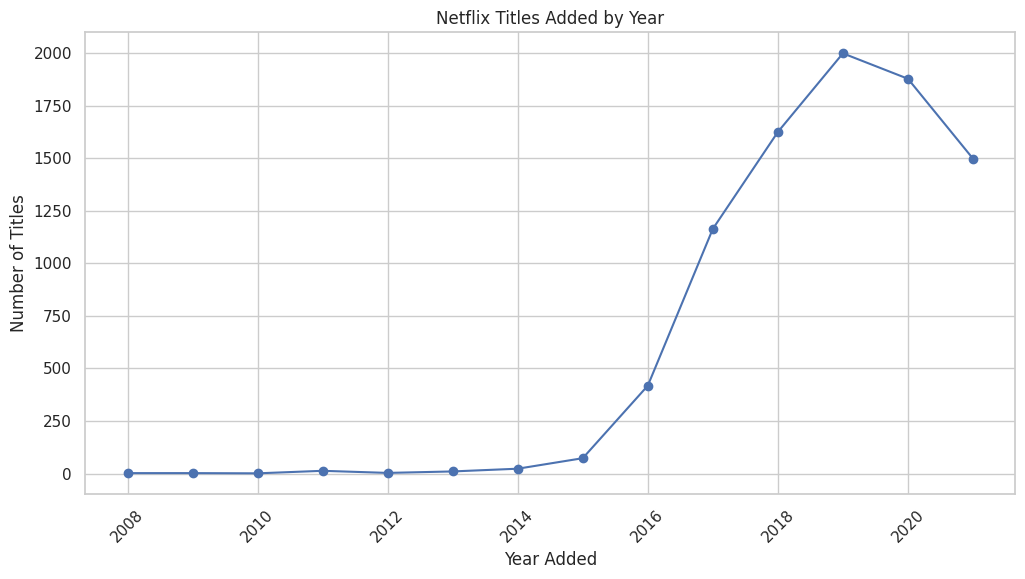

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    titles_added_by_year.index,
    titles_added_by_year.values,
    marker="o"
)

plt.title("Netflix Titles Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [71]:
rating_counts = df["rating"].value_counts()

rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


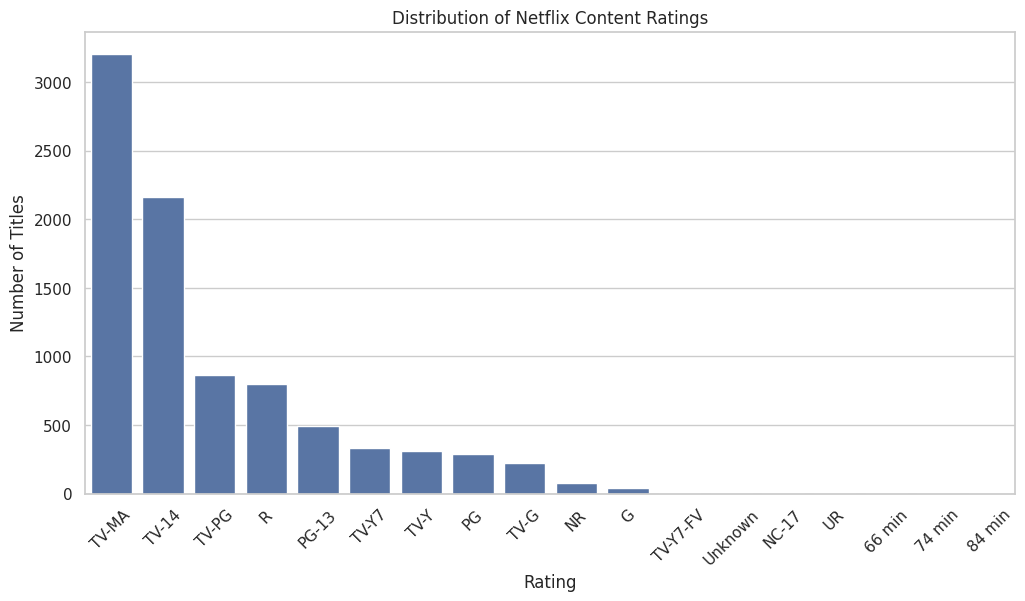

In [72]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [73]:
country_data = (
    df["country"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
)

country_counts = country_data.value_counts()

country_counts.head(15)

,count
country,
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


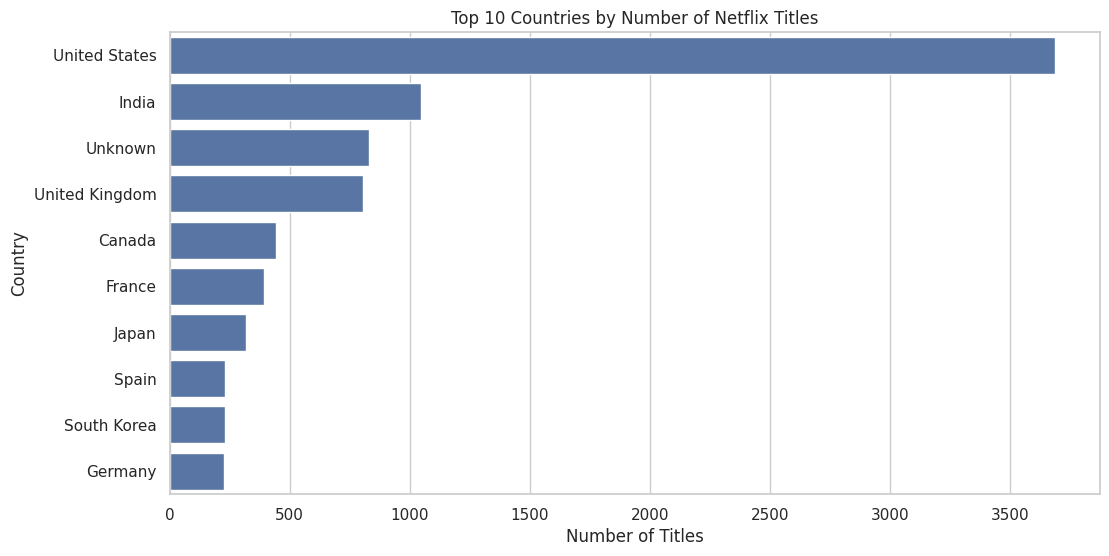

In [74]:
top_countries = country_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [75]:
genre_data = (
    df["listed_in"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
)

genre_counts = genre_data.value_counts()

genre_counts.head(20)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


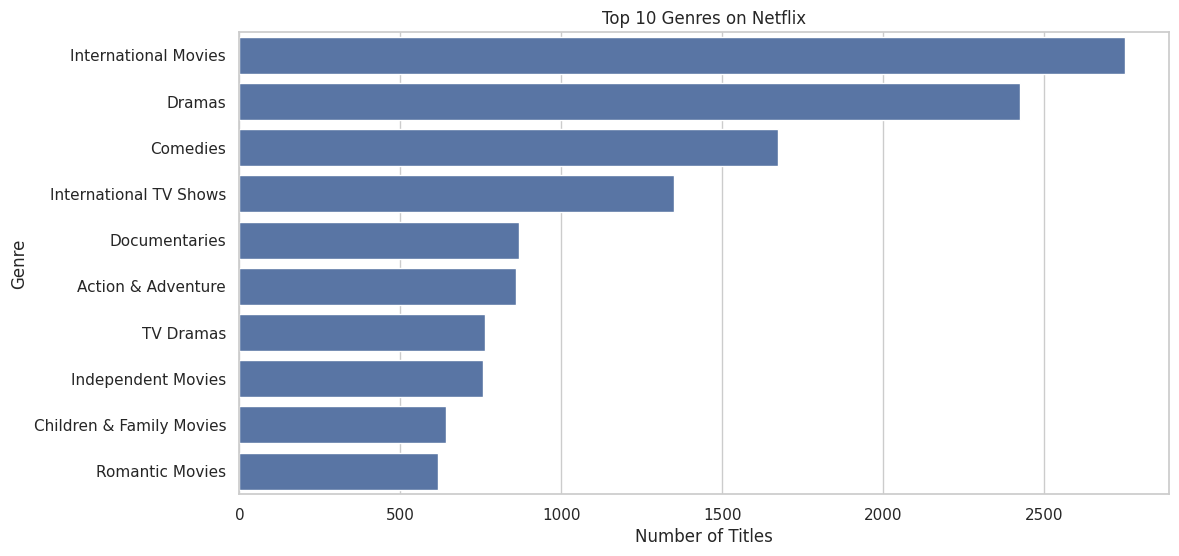

In [76]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [77]:
director_counts = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
)

director_counts.head(15)

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


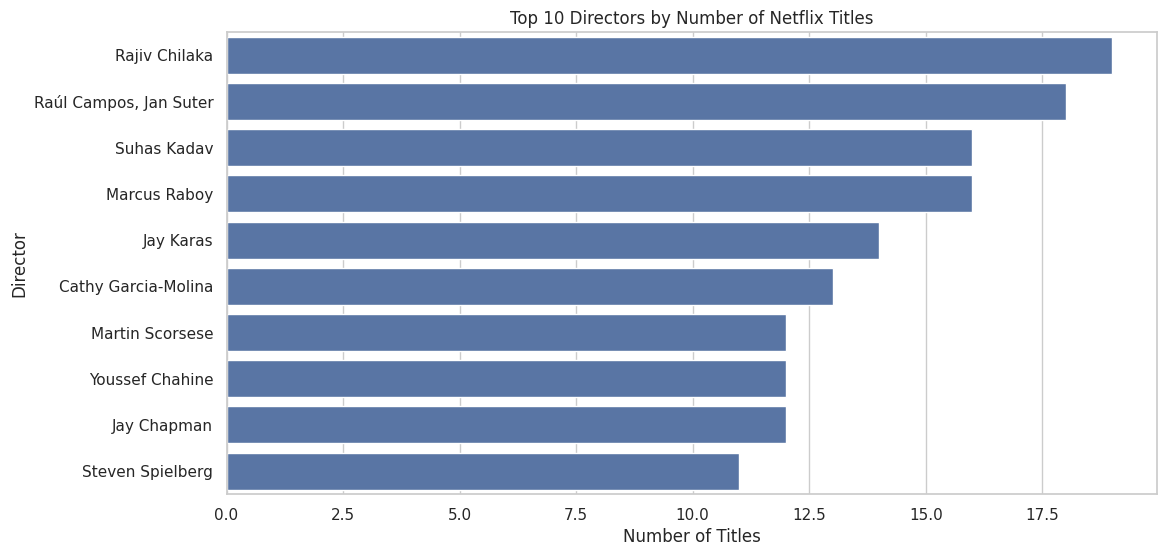

In [78]:
top_directors = director_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

In [79]:
# Extract numeric duration
df["duration_value"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

df[["type", "duration", "duration_value"]].head(10)

,type,duration,duration_value
0,Movie,90 min,90.0
1,TV Show,2 Seasons,2.0
2,TV Show,1 Season,1.0
3,TV Show,1 Season,1.0
4,TV Show,2 Seasons,2.0
5,TV Show,1 Season,1.0
6,Movie,91 min,91.0
7,Movie,125 min,125.0
8,TV Show,9 Seasons,9.0
9,Movie,104 min,104.0


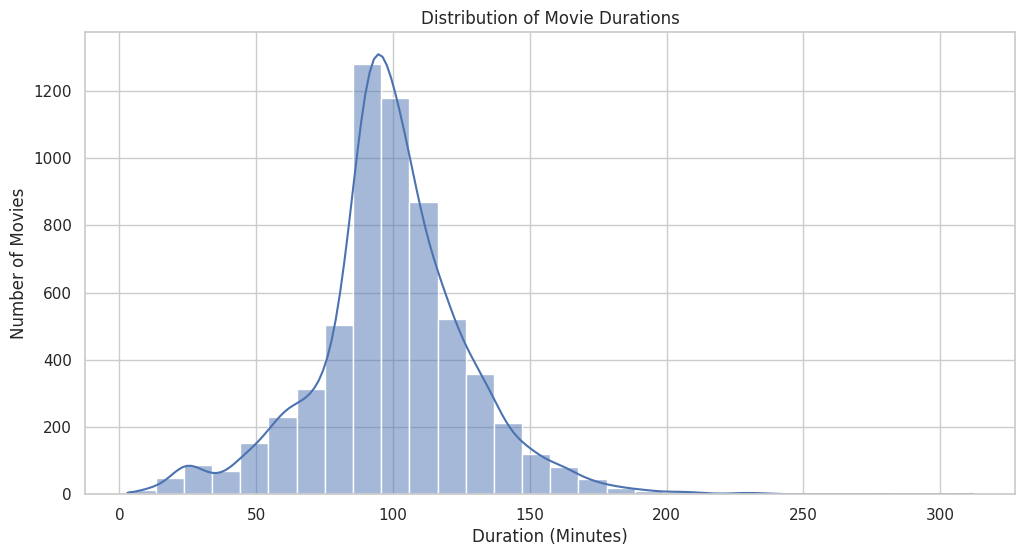

In [80]:
movies = df[
    (df["type"] == "Movie") &
    (df["duration_value"].notna())
]

plt.figure(figsize=(12, 6))

sns.histplot(
    movies["duration_value"],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [81]:
average_movie_duration = movies["duration_value"].mean()

print(
    f"Average movie duration: {average_movie_duration:.2f} minutes"
)

Average movie duration: 99.58 minutes


In [82]:
type_year = pd.crosstab(
    df["release_year"],
    df["type"]
)

type_year.tail(20)

type,Movie,TV Show
release_year,,
2002,44,7
2003,51,10
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,23
2009,118,34
2010,154,40


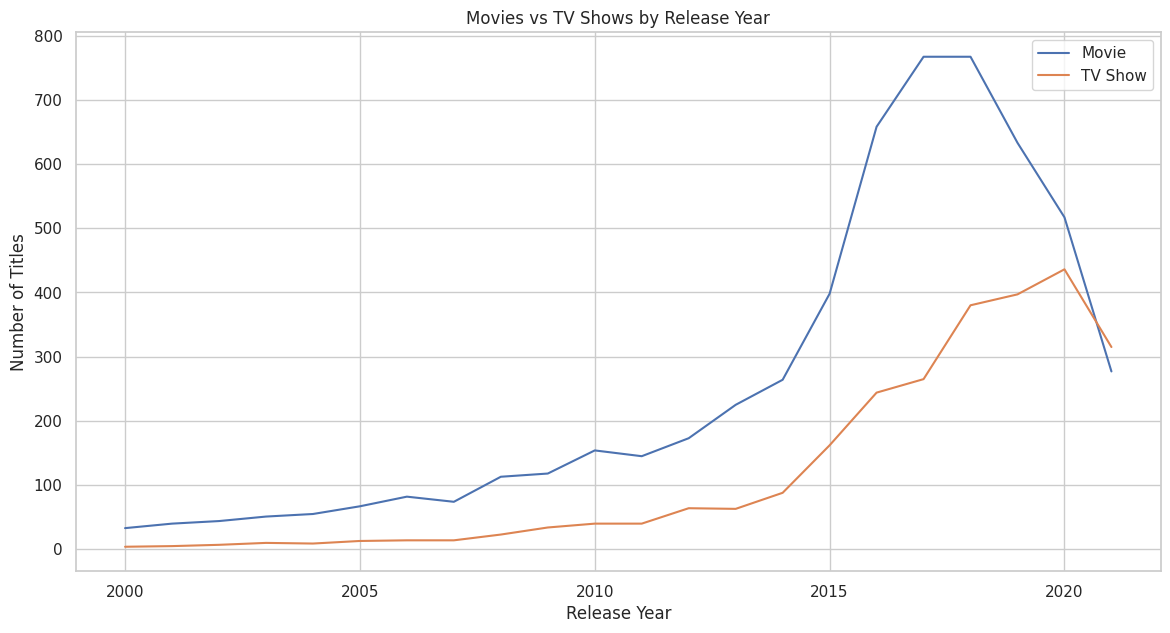

In [83]:
type_year_recent = type_year[
    type_year.index >= 2000
]

plt.figure(figsize=(14, 7))

plt.plot(
    type_year_recent.index,
    type_year_recent["Movie"],
    label="Movie"
)

plt.plot(
    type_year_recent.index,
    type_year_recent["TV Show"],
    label="TV Show"
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()

plt.show()

In [84]:
correlation_columns = [
    "release_year",
    "year_added",
    "month_added",
    "duration_value"
]

correlation_data = df[
    correlation_columns
].copy()

correlation_matrix = correlation_data.corr()

correlation_matrix

,release_year,year_added,month_added,duration_value
release_year,1.000000,0.110473,-0.039316,-0.249182
year_added,0.110473,1.000000,-0.160555,0.016436
month_added,-0.039316,-0.160555,1.000000,-0.016876
duration_value,-0.249182,0.016436,-0.016876,1.000000


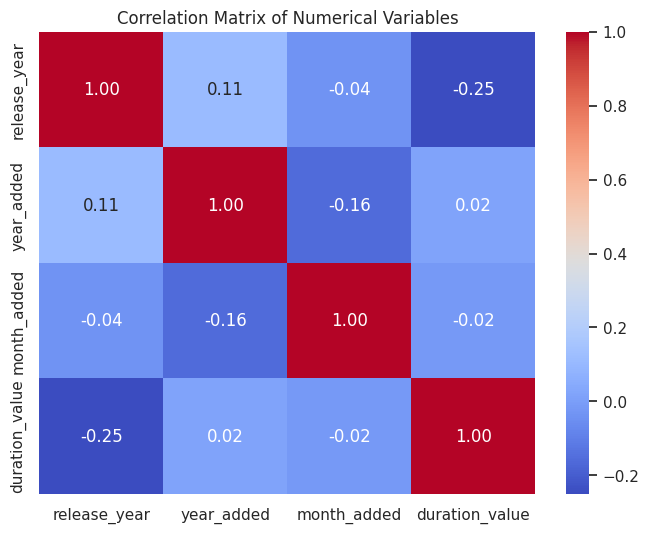

In [85]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [86]:
year_type = pd.crosstab(
    df["year_added"],
    df["type"]
)

year_type

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,4
2014.0,19,4
2015.0,56,17
2016.0,253,165


Top 10 Years with the Most Netflix Content Added:
year_added
2019.0    1999
2020.0    1878
2018.0    1625
2021.0    1498
2017.0    1164
2016.0     418
2015.0      73
2014.0      23
2011.0      13
2013.0      10
Name: count, dtype: int64


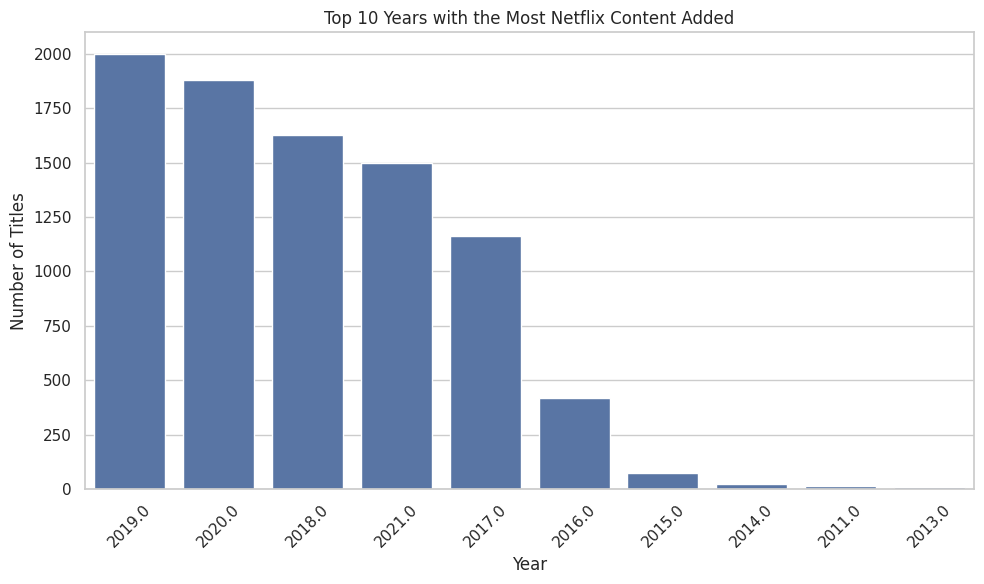

In [87]:
# Top 10 Years with the Most Netflix Content Added

top_added_years = (
    df["year_added"]
    .dropna()
    .value_counts()
    .head(10)
)

print("Top 10 Years with the Most Netflix Content Added:")
print(top_added_years)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_added_years.index.astype(str),
    y=top_added_years.values
)

plt.title("Top 10 Years with the Most Netflix Content Added")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [88]:
summary = pd.DataFrame({
    "Metric": [
        "Total Titles",
        "Total Movies",
        "Total TV Shows",
        "Unique Directors",
        "Unique Countries",
        "Unique Ratings",
        "Unique Genres"
    ],
    "Value": [
        len(df),
        (df["type"] == "Movie").sum(),
        (df["type"] == "TV Show").sum(),
        df["director"].replace("Unknown", np.nan).nunique(),
        country_counts.index.nunique(),
        df["rating"].replace("Unknown", np.nan).nunique(),
        genre_counts.index.nunique()
    ]
})

summary

,Metric,Value
0,Total Titles,8807
1,Total Movies,6131
2,Total TV Shows,2676
3,Unique Directors,4528
4,Unique Countries,128
5,Unique Ratings,17
6,Unique Genres,42


In [89]:
total_titles = len(df)

total_movies = (df["type"] == "Movie").sum()

total_tv_shows = (df["type"] == "TV Show").sum()

movie_percentage = total_movies / total_titles * 100

tv_percentage = total_tv_shows / total_titles * 100

most_common_type = df["type"].mode()[0]

most_common_rating = df[
    df["rating"] != "Unknown"
]["rating"].mode()[0]

most_common_genre = genre_counts.index[0]

top_country = country_counts.index[0]

print("========== KEY INSIGHTS ==========")

print(f"Total Netflix titles: {total_titles}")

print(f"Total movies: {total_movies}")

print(f"Total TV shows: {total_tv_shows}")

print(f"Movie percentage: {movie_percentage:.2f}%")

print(f"TV show percentage: {tv_percentage:.2f}%")

print(f"Most common content type: {most_common_type}")

print(f"Most common rating: {most_common_rating}")

print(f"Most common genre: {most_common_genre}")

print(f"Country with most titles: {top_country}")

========== KEY INSIGHTS ==========
Total Netflix titles: 8807
Total movies: 6131
Total TV shows: 2676
Movie percentage: 69.62%
TV show percentage: 30.38%
Most common content type: Movie
Most common rating: TV-MA
Most common genre: International Movies
Country with most titles: United States


In [90]:
print("Final dataset shape:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Final dataset shape: (8807, 16)

Remaining missing values:
show_id              0
type                 0
title                0
director             0
cast                 0
country              0
date_added           0
release_year         0
rating               0
duration             0
listed_in            0
description          0
date_added_clean    98
year_added          98
month_added         98
duration_value       3
dtype: int64

Duplicate rows:
0


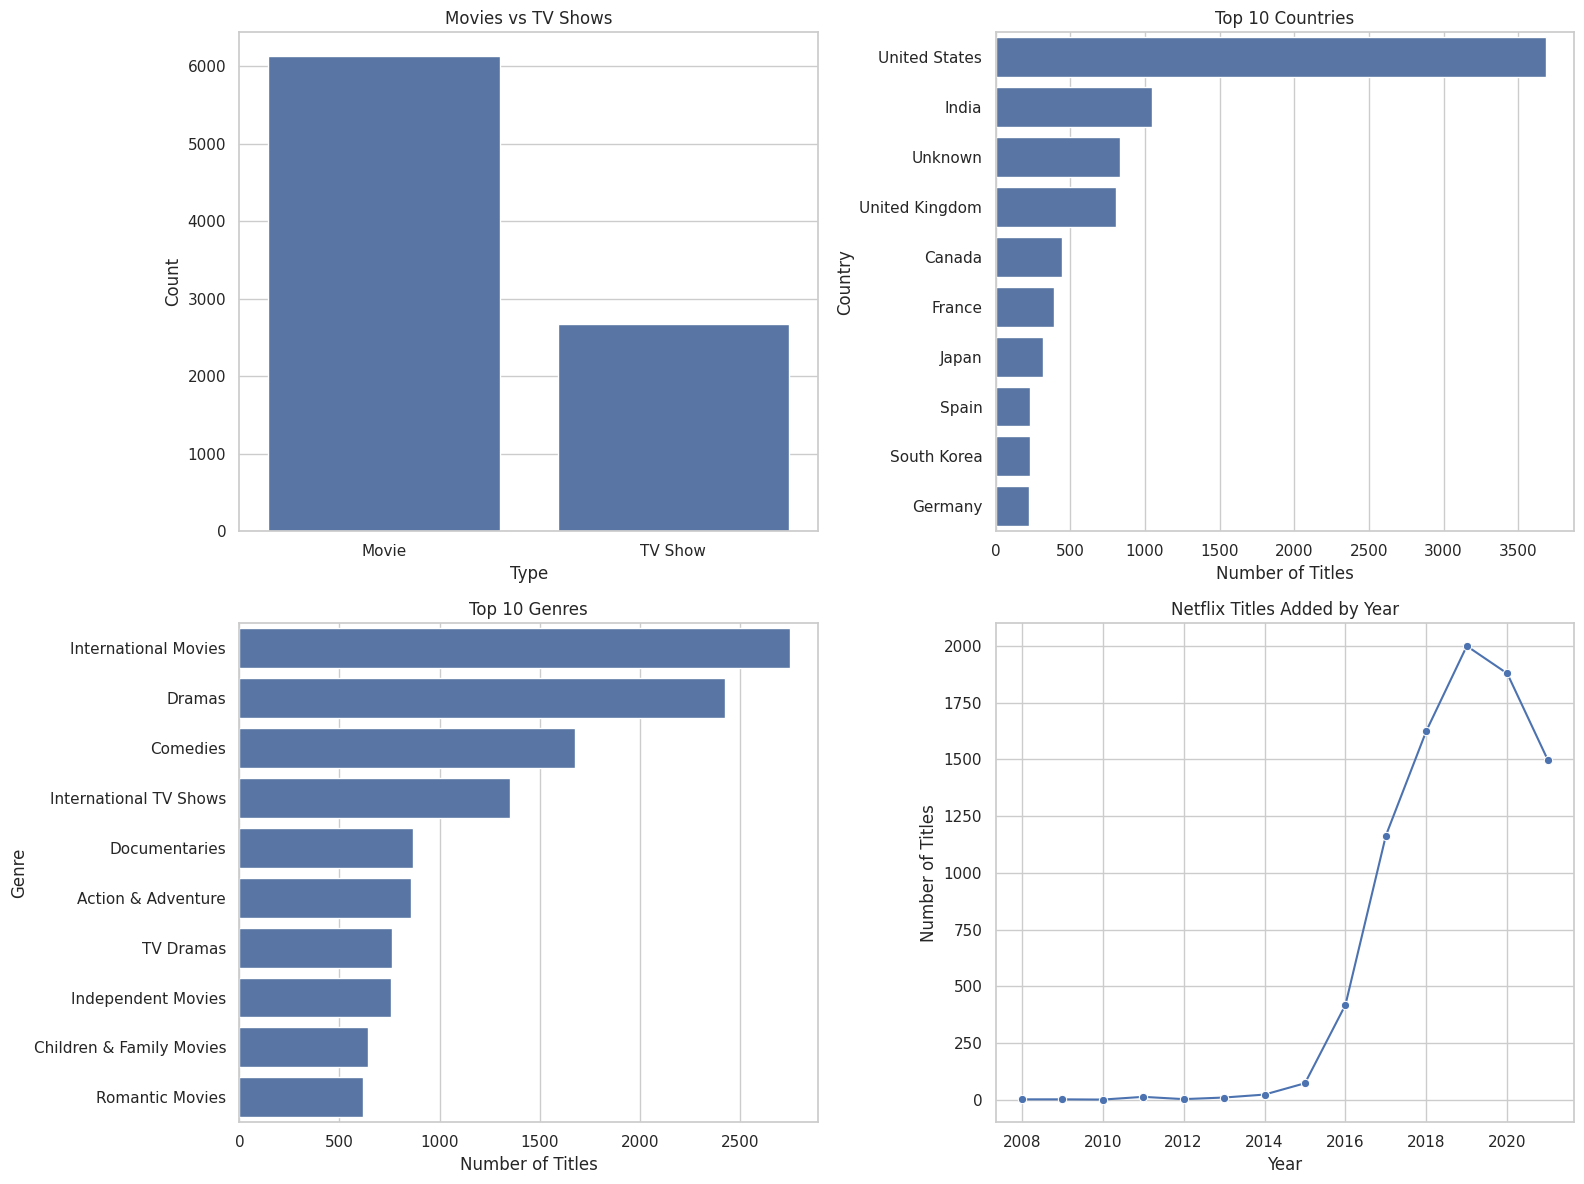

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Movies vs TV Shows
sns.countplot(
    data=df,
    x="type",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Movies vs TV Shows")
axes[0, 0].set_xlabel("Type")
axes[0, 0].set_ylabel("Count")


# 2. Top Countries
top_countries = country_counts.head(10)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Top 10 Countries")
axes[0, 1].set_xlabel("Number of Titles")
axes[0, 1].set_ylabel("Country")


# 3. Top Genres
top_genres = genre_counts.head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Top 10 Genres")
axes[1, 0].set_xlabel("Number of Titles")
axes[1, 0].set_ylabel("Genre")


# 4. Titles Added by Year
sns.lineplot(
    x=titles_added_by_year.index,
    y=titles_added_by_year.values,
    marker="o",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Netflix Titles Added by Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Number of Titles")

plt.tight_layout()

plt.show()

# Conclusion

The Exploratory Data Analysis of the Netflix Movies and TV Shows dataset revealed several important patterns in Netflix's content library.

The dataset contains both Movies and TV Shows, with Movies representing the larger share of the available titles. The analysis of release years shows that a significant portion of Netflix's content was released during recent years, indicating a strong focus on modern content.

The analysis of content ratings helped identify the most common audience classifications, while genre analysis revealed the most frequently represented categories on the platform.

Country-level analysis showed that content production is concentrated in a few major countries, while the genre analysis demonstrated the diversity of Netflix's catalog.

The analysis of movie durations showed the typical length of movies available on Netflix. The correlation analysis was also performed on numerical variables to identify relationships between release year, year added, month added, and movie duration.

Overall, the EDA helped identify important trends, distributions, and patterns in Netflix's content library and demonstrated how statistical analysis and visualization can be used to derive meaningful insights from real-world data.